# Unsupervised Learning & K-Means Clustering (7/2/26)

---

*Codecademy — MLE Path: Unsupervised Learning. Concise grad-student notes.*

## Intro: What is Unsupervised Learning?

**Unsupervised learning** finds patterns in **unlabelled** data. There are no target values to predict — the algorithm uses the underlying distribution of the features to figure out groups of similar points on its own.

Contrast with **supervised learning**, where every training example comes with a label:
- Regression predicts a continuous outcome (e.g. housing prices).
- Classification predicts a category (e.g. spam vs. not spam).

Often the training data isn't labelled that way, and that's where unsupervised learning comes in.

### Why it matters

It powers a lot of real-world systems: image recognition, ride-share demand forecasting, Snapchat filters, and more. Three primary uses:

1. **Clustering** — group similar points together (e.g. finding disease-outbreak clusters, or grouping semantically related words for a word cloud).
2. **Dimensionality reduction / feature extraction** — shrink a dataset with many features down to a smaller set before feeding it to a supervised model.
3. **Automated labelling / tagging** — categorize uncategorized data, so you can then run the usual supervised classification or regression on it.

### What this module covers

Two of the most common techniques:

- **Principal Component Analysis (PCA)** — mainly for dimensionality reduction.
- **K-Means Clustering** — mainly for clustering problems.

By the end you should be able to: reduce dimensions with PCA, classify images using PCA, find clusters with K-Means, and extract features with both.

# K-Means Clustering

## Introduction to Clustering

Real-world data often isn't sorted into categories and has no labelled answers. **Clustering** is the most well-known unsupervised technique for finding structure in this kind of unlabelled data: it groups similar points together into **clusters**.

Common applications:
- **Recommendation engines** — group products to personalize the user experience.
- **Search engines** — group news topics and search results.
- **Market segmentation** — group customers by geography, demography, and behavior.
- **Image segmentation** — medical imaging, or road-scene segmentation for self-driving cars.
- **Text clustering** — group similar texts by word usage.

The **Iris dataset** is a classic example: measurements of sepals and petals for 150 iris flowers (50 from each of three species). When visualized, the flowers naturally fall into three distinct clusters. This lesson is about finding those clusters.

## K-Means Clustering

Goal of clustering: keep similar data in the same group and different data in different groups. Two questions fall out of that:
1. How many groups do we choose?
2. How do we define similarity?

**K-Means** is the most popular clustering algorithm, and it addresses both:
- **k** = the number of clusters we expect to find.
- **Means** = the average distance from data to each cluster center (the **centroid**), which we try to minimize.

### The algorithm (iterative)

1. Place **k** random centroids for the initial clusters.
2. Assign each data sample to its nearest centroid.
3. Recalculate each centroid as the average of the points assigned to it.
4. Repeat steps 2 and 3 until convergence.

**Convergence** = points stop moving between clusters and the centroids stabilize. This whole iterative process is called **training**.

Once the clusters are settled, we can take a new unlabelled point and quickly assign it to the right cluster. That's called **inference**.

In practice, knowing how many clusters to look for (choosing k) can be tricky. We'll implement k-means first the hard way (to understand it), then the easy way with scikit-learn.

## The Iris Dataset

sklearn ships some sample datasets built in, including **Iris**: measurements of sepals and petals for 3 iris species — *setosa*, *versicolor*, *virginica*.

- The **sepal** encases and protects the flower in bud stage; the **petal** is the leaflike, often colorful part.
- Each **row is a sample** (one flower). Each **column is a feature**.
- The four features are:
  - Column 0: sepal length
  - Column 1: sepal width
  - Column 2: petal length
  - Column 3: petal width

The 3 species are what we'll try to recover as clusters later — using only the feature measurements, not the labels.

In [1]:
from sklearn import datasets

iris = datasets.load_iris()

# the feature measurements live in .data (150 samples x 4 features)
print(iris.data[:3])
# -> [[5.1 3.5 1.4 0.2]
#     [4.9 3.  1.4 0.2]
#     [4.7 3.2 1.3 0.2]]
print(iris.data.shape)      # -> (150, 4)
print(iris.feature_names)   # -> sepal length, sepal width, petal length, petal width


[[5.1 3.5 1.4 0.2]
 [4.9 3.  1.4 0.2]
 [4.7 3.2 1.3 0.2]]
(150, 4)
['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']


### Exploring the dataset

An sklearn dataset carries more than just the raw data:
- **`iris.data`** — the sample measurements (each row is one plant).
- **`iris.target`** — the **ground truth**: which species (0, 1, 2) each flower actually is. In a real clustering problem the data is unlabelled and you *won't* have this. Here we ignore the targets while clustering, then use them afterward to check our work.
- **`iris.DESCR`** — a text description of the dataset. Always worth reading.

From `DESCR`, two facts: the Iris dataset was published in **1936** (R.A. Fisher), and the measurements are in **centimeters**.

In [2]:
# import codecademylib3_seaborn   # Codecademy-only helper; not available here
import matplotlib.pyplot as plt
from sklearn import datasets

iris = datasets.load_iris()

print(iris.data)                        # all sample measurements (one row per plant)
print(iris.target)                      # ground-truth species: 0, 1, or 2
print(iris.data[0, :], iris.target[0])  # one row + its target -> [5.1 3.5 1.4 0.2] 0
print(iris.DESCR)                        # full dataset description (published 1936, units in cm)


[[5.1 3.5 1.4 0.2]
 [4.9 3.  1.4 0.2]
 [4.7 3.2 1.3 0.2]
 [4.6 3.1 1.5 0.2]
 [5.  3.6 1.4 0.2]
 [5.4 3.9 1.7 0.4]
 [4.6 3.4 1.4 0.3]
 [5.  3.4 1.5 0.2]
 [4.4 2.9 1.4 0.2]
 [4.9 3.1 1.5 0.1]
 [5.4 3.7 1.5 0.2]
 [4.8 3.4 1.6 0.2]
 [4.8 3.  1.4 0.1]
 [4.3 3.  1.1 0.1]
 [5.8 4.  1.2 0.2]
 [5.7 4.4 1.5 0.4]
 [5.4 3.9 1.3 0.4]
 [5.1 3.5 1.4 0.3]
 [5.7 3.8 1.7 0.3]
 [5.1 3.8 1.5 0.3]
 [5.4 3.4 1.7 0.2]
 [5.1 3.7 1.5 0.4]
 [4.6 3.6 1.  0.2]
 [5.1 3.3 1.7 0.5]
 [4.8 3.4 1.9 0.2]
 [5.  3.  1.6 0.2]
 [5.  3.4 1.6 0.4]
 [5.2 3.5 1.5 0.2]
 [5.2 3.4 1.4 0.2]
 [4.7 3.2 1.6 0.2]
 [4.8 3.1 1.6 0.2]
 [5.4 3.4 1.5 0.4]
 [5.2 4.1 1.5 0.1]
 [5.5 4.2 1.4 0.2]
 [4.9 3.1 1.5 0.2]
 [5.  3.2 1.2 0.2]
 [5.5 3.5 1.3 0.2]
 [4.9 3.6 1.4 0.1]
 [4.4 3.  1.3 0.2]
 [5.1 3.4 1.5 0.2]
 [5.  3.5 1.3 0.3]
 [4.5 2.3 1.3 0.3]
 [4.4 3.2 1.3 0.2]
 [5.  3.5 1.6 0.6]
 [5.1 3.8 1.9 0.4]
 [4.8 3.  1.4 0.3]
 [5.1 3.8 1.6 0.2]
 [4.6 3.2 1.4 0.2]
 [5.3 3.7 1.5 0.2]
 [5.  3.3 1.4 0.2]
 [7.  3.2 4.7 1.4]
 [6.4 3.2 4.5 1.5]
 [6.9 3.1 4.

## Visualize Before K-Means

Before clustering, it helps to look at the data. We have 4 features, but a scatter plot only shows 2 dimensions at a time, so we pick two features to plot.

To pull a single column out of the data matrix, use NumPy slicing:

`matrix[:, 0]` means `[all_rows, column_0]`.

Column layout reminder: 0 = sepal length, 1 = sepal width, 2 = petal length, 3 = petal width.

Exercise: plot **sepal length (column 0)** vs. **sepal width (column 1)**.

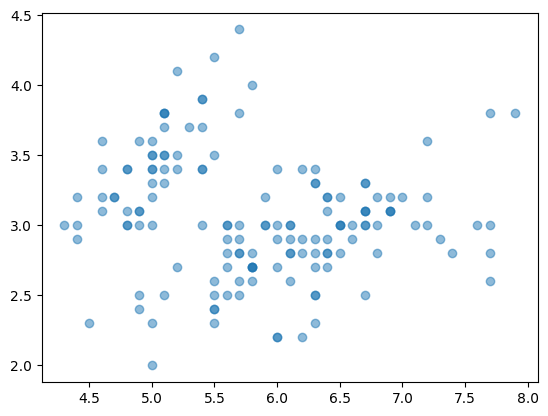

In [3]:
# import codecademylib3_seaborn   # Codecademy-only helper; not available here
import matplotlib.pyplot as plt
from sklearn import datasets

iris = datasets.load_iris()

# Store iris.data
samples = iris.data

# Create x and y
x = samples[:, 0]   # sepal length
y = samples[:, 1]   # sepal width

# Plot x and y  (alpha=0.5 -> semi-transparent, so overlapping points show as denser)
plt.scatter(x, y, alpha=0.5)

# Show the plot
plt.show()


## Implementing K-Means the hard way

The algorithm again:
1. Place **k** random centroids for the initial clusters.
2. Assign each sample to the nearest centroid.
3. Update each centroid to the mean of its assigned samples.
4. Repeat steps 2 and 3 until convergence.

### Step 1: place k random centroids

We expect 3 species, so use **k = 3**. (In real problems you won't know k up front — more on choosing it later.)

We work in 2D using sepal length (x) and sepal width (y). A centroid is just an (x, y) point, so we pick 3 random ones inside the range of the data with NumPy.

[[5.32833371 2.43949131]
 [5.91406579 3.11294724]
 [6.71156923 4.32431881]]


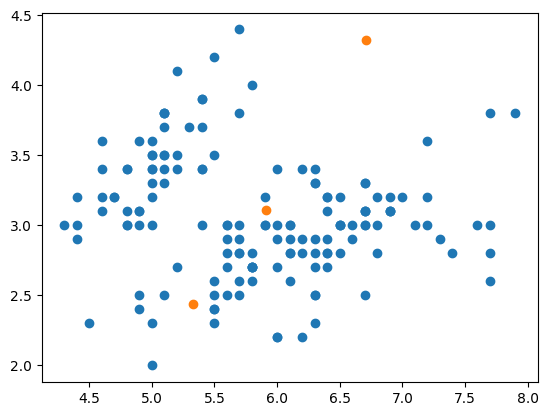

In [4]:
# import codecademylib3_seaborn   # Codecademy-only helper; not available here
import matplotlib.pyplot as plt
import numpy as np
from sklearn import datasets

iris = datasets.load_iris()

samples = iris.data

x = samples[:, 0]
y = samples[:, 1]

# Number of clusters
k = 3

# Create x coordinates of k random centroids
centroids_x = np.random.uniform(min(x), max(x), k)

# Create y coordinates of k random centroids
centroids_y = np.random.uniform(min(y), max(y), k)

# Create centroids array
centroids = np.array(list(zip(centroids_x, centroids_y)))
print(centroids)

# Make a scatter plot of x, y
plt.scatter(x, y)

# Make a scatter plot of the centroids
plt.scatter(centroids_x, centroids_y)

# Display plot
plt.show()


### Step 2: assign each point to the nearest centroid

Now that we have 3 random centroids, we label every data point with the centroid it's closest to. "Closest" needs a **distance formula**.

**Two common distances (both between two points on a 2D plane):**
- **Euclidean** — the straight-line distance, the hypotenuse of the right triangle connecting the two points. This is the one we'll use.
- **Taxicab (Manhattan)** — the distance you'd travel along the two shorter sides of that triangle, like a taxi driving around a city block. Always longer than Euclidean.

Euclidean distance between points $a$ and $b$:

$$d(a, b) = \sqrt{(a_x - b_x)^2 + (a_y - b_y)^2}$$

**The plan:**
1. Write a `distance()` function using that formula.
2. For each of the 150 samples, compute its distance to all 3 centroids — giving a list like `[15, 20, 5]`.
3. Use **`np.argmin(distances)`** to grab the *index* of the smallest distance. For `[15, 20, 5]` that's index **2** (the 3rd centroid), so the point is assigned to centroid 2.
4. Store that index in a `labels` array — one label (0, 1, or 2) per sample.

`argmin` returns the *position* of the minimum, not the value — which is exactly the centroid number we want to record.

In [5]:
# import codecademylib3_seaborn   # Codecademy-only helper; not available here
import matplotlib.pyplot as plt
import numpy as np
from sklearn import datasets

iris = datasets.load_iris()

samples = iris.data

x = samples[:, 0]
y = samples[:, 1]

sepal_length_width = np.array(list(zip(x, y)))

# Step 1: Place K random centroids

k = 3

centroids_x = np.random.uniform(min(x), max(x), size=k)
centroids_y = np.random.uniform(min(y), max(y), size=k)

centroids = np.array(list(zip(centroids_x, centroids_y)))

# Step 2: Assign samples to nearest centroid

# Distance formula
def distance(a, b):
  one = (a[0] - b[0]) ** 2
  two = (a[1] - b[1]) ** 2
  distance = (one + two) ** 0.5
  return distance

# Cluster labels for each point (either 0, 1, or 2)
labels = np.zeros(len(samples))

# A function that assigns the nearest centroid to a sample
def assign_to_centroid(sample, centroids):
  k = len(centroids)
  distances = np.zeros(k)
  for i in range(k):
    distances[i] = distance(sample, centroids[i])
    closest_centroid = np.argmin(distances)
  return closest_centroid

# Assign the nearest centroid to each sample
for i in range(len(samples)):
  labels[i] = assign_to_centroid(samples[i], centroids)

# Print labels
print(labels)


[1. 2. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 2. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 2. 1. 1. 1. 1. 1. 1.
 1. 1. 0. 0. 0. 2. 0. 2. 0. 2. 0. 2. 2. 2. 2. 2. 2. 0. 2. 2. 2. 2. 2. 2.
 2. 2. 2. 0. 0. 0. 2. 2. 2. 2. 2. 2. 2. 2. 0. 2. 2. 2. 2. 2. 2. 2. 2. 2.
 2. 2. 2. 2. 0. 2. 0. 2. 0. 0. 2. 0. 0. 0. 0. 2. 0. 2. 2. 0. 0. 0. 0. 2.
 0. 2. 0. 2. 0. 0. 2. 2. 2. 0. 0. 0. 2. 2. 2. 0. 0. 0. 2. 0. 0. 0. 2. 0.
 0. 0. 2. 0. 2. 2.]


### Step 3: update the centroids

The algorithm recap:
1. Place **k** random centroids for the initial clusters.
2. Assign data samples to the nearest centroid.
3. **Update centroids based on the above-assigned data samples.**
4. Repeat steps 2 and 3 until convergence.

Now that every point has a `label` (which centroid it's closest to), move each centroid to the **average position of the points assigned to it** — using `.mean()`.

In [6]:
# import codecademylib3_seaborn   # Codecademy-only helper; not available here
import matplotlib.pyplot as plt
import numpy as np
from sklearn import datasets
from copy import deepcopy

iris = datasets.load_iris()

samples = iris.data

x = samples[:,0]
y = samples[:,1]

sepal_length_width = np.array(list(zip(x, y)))

# Step 1: Place K random centroids

k = 3

centroids_x = np.random.uniform(min(x), max(x), size=k)
centroids_y = np.random.uniform(min(y), max(y), size=k)

centroids = np.array(list(zip(centroids_x, centroids_y)))

# Step 2: Assign samples to nearest centroid

# Distance formula

def distance(a, b):
  one = (a[0] - b[0]) **2
  two = (a[1] - b[1]) **2
  distance = (one+two) ** 0.5
  return distance

# Cluster labels for each point (either 0, 1, or 2)

labels = np.zeros(len(samples))

# A function that assigns the nearest centroid to a sample

def assign_to_centroid(sample, centroids):
  k = len(centroids)
  distances = np.zeros(k)
  for i in range(k):
    distances[i] = distance(sample, centroids[i])
  closest_centroid = np.argmin(distances)
  return closest_centroid

# Assign the nearest centroid to each sample

for i in range(len(samples)):
  labels[i] = assign_to_centroid(samples[i], centroids)

# Step 3: Update centroids
centroids_old =  deepcopy(centroids)

#Updating Centroids
for i in range(k): 
  points = [] 
  for j in range(len(sepal_length_width)):
    if labels[j] == i: 
      points.append(sepal_length_width[j])
  centroids[i] = np.mean(points, axis = 0)

print("Centroids Old = ", centroids_old)
print("New Centroids = ", centroids)


Centroids Old =  [[7.32616284 4.09191743]
 [7.44665283 3.06228133]
 [7.23080421 2.38919306]]
New Centroids =  [[5.39117647 3.65882353]
 [6.75277778 3.11666667]
 [5.62625    2.775     ]]


### Step 4: repeat until convergence

The algorithm recap:
1. Place **k** random centroids for the initial clusters.
2. Assign data samples to the nearest centroid.
3. Update centroids based on the above-assigned data samples.
4. **Repeat Steps 2 and 3 until convergence.**

Steps 2 and 3 (assign, then update) go inside a `while` loop, repeated until the centroids **stabilize**.

To detect stabilization, track an `errors` array: one entry per centroid, each holding the distance between the updated `centroids[i]` and the old `centroids_old[i]`. The loop keeps running as long as any of those errors is nonzero, and stops once all `k` errors are exactly 0 — i.e. no centroid moved on the last update.

**Subtlety in `while error.all() != 0:`** — `.all()` is only `True` when *every* entry in `error` is nonzero. So the moment even **one** centroid's error hits exactly 0 (that single centroid stopped moving), `.all()` flips to `False` and the loop exits — even if the other two centroids haven't fully converged yet. This is the real Codecademy solution as written; a stricter version would use `error.any() != 0` (loop while *any* centroid is still moving). In practice it still converges to a reasonable result on Iris because the centroids tend to settle around the same time.

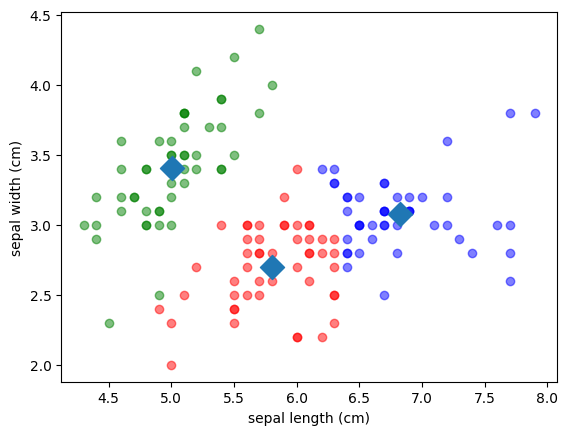

In [7]:
# import codecademylib3_seaborn   # Codecademy-only helper; not available here
import matplotlib.pyplot as plt
import numpy as np
from sklearn import datasets
from copy import deepcopy

iris = datasets.load_iris()

samples = iris.data

x = samples[:,0]
y = samples[:,1]

sepal_length_width = np.array(list(zip(x, y)))

# Step 1: Place K random centroids

k = 3

centroids_x = np.random.uniform(min(x), max(x), size=k)
centroids_y = np.random.uniform(min(y), max(y), size=k)

centroids = np.array(list(zip(centroids_x, centroids_y)))

def distance(a, b):
  one = (a[0] - b[0]) ** 2
  two = (a[1] - b[1]) ** 2
  distance = (one + two) ** 0.5
  return distance

# A function that assigns the nearest centroid to a sample
def assign_to_centroid(sample, centroids):
  k = len(centroids)
  distances = np.zeros(k)
  for i in range(k):
    distances[i] = distance(sample, centroids[i])
  closest_centroid = np.argmin(distances)
  return closest_centroid

# To store the value of centroids when it updates
centroids_old = np.zeros(centroids.shape)

# Cluster labeles (either 0, 1, or 2)
labels = np.zeros(len(samples))

distances = np.zeros(3)

# Initialize error:
error = np.zeros(3)

for i in range(k):
  error[i] = distance(centroids[i], centroids_old[i])

# Repeat Steps 2 and 3 until convergence:

while error.all() != 0:

  # Step 2: Assign samples to nearest centroid

  for i in range(len(samples)):
    labels[i] = assign_to_centroid(samples[i], centroids)

  # Step 3: Update centroids

  centroids_old = deepcopy(centroids)

  for i in range(k):
    points = [sepal_length_width[j] for j in range(len(sepal_length_width)) if labels[j] == i]
    centroids[i] = np.mean(points, axis=0)
    error[i] = distance(centroids[i], centroids_old[i])

colors = ['r', 'g', 'b']

for i in range(k):
  points = np.array([sepal_length_width[j] for j in range(len(samples)) if labels[j] == i])
  plt.scatter(points[:, 0], points[:, 1], c=colors[i], alpha=0.5)

plt.scatter(centroids[:, 0], centroids[:, 1], marker='D', s=150)

plt.xlabel('sepal length (cm)')
plt.ylabel('sepal width (cm)')

plt.show()


## Implementing K-Means with scikit-learn

Writing the algorithm from scratch is great for understanding it, but it's time-consuming and error-prone. **scikit-learn** does it more efficiently:

- It scales to datasets with as many features as your computer can handle — so we can now use all **4** Iris features instead of just the 2 (sepal length/width) we used for the hard-way version.
- It's a widely-used, well-tested open-source library, so it's far less likely to contain bugs, and it's easy to find help online if you get stuck.

```python
from sklearn.cluster import KMeans
```

- **Step 1** (place centroids): build a model with the number of clusters via `n_clusters`:
  ```python
  model = KMeans(n_clusters=k)
  ```
- **Steps 2 & 3** (assign + update, repeated to convergence): one call —
  ```python
  model.fit(X)
  ```
- **Inference**: predict which cluster each sample belongs to —
  ```python
  model.predict(X)
  ```

What took ~30 lines of loops, distance functions, and a convergence check by hand collapses to `KMeans(n_clusters=k).fit(X)`.

In [8]:
# import codecademylib3_seaborn   # Codecademy-only helper; not available here
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.cluster import KMeans

# From sklearn.cluster, import Kmeans class

iris = datasets.load_iris()

samples = iris.data

# Use KMeans() to create a model that finds 3 clusters
model = KMeans(n_clusters = 3)

# Use .fit() to fit the model to samples
model.fit(samples)


# Use .predict() to determine the labels of samples
labels = model.predict(samples)


# Print the labels
print(labels)


[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 2 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 2 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 1 2 2 2 2 1 2 2 2 2
 2 2 1 1 2 2 2 2 1 2 1 2 1 2 2 1 1 2 2 2 2 2 1 2 2 2 2 1 2 2 2 1 2 2 2 1 2
 2 1]


## New Data?

Once a model has been fit (trained), it can be reused: feed it brand-new, never-before-seen samples and get cluster labels back via `.predict()` — no retraining needed. This is **inference**.

Example: suppose you go to the florist and buy 3 more irises with measurements

```python
new_samples = [[5.1, 3.5, 1.4, 0.2],
               [3.4, 3.1, 1.6, 0.3],
               [4.9, 3.0, 1.4, 0.2]]
```

Feed `new_samples` into the already-fitted `model` to get their cluster labels — the model just measures distance to the 3 centroids it already learned and assigns each new point to the closest one.

In [9]:
# import codecademylib3_seaborn   # Codecademy-only helper; not available here
import matplotlib.pyplot as plt
import numpy as np
from sklearn import datasets
from sklearn.cluster import KMeans

iris = datasets.load_iris()

samples = iris.data

model = KMeans(n_clusters=3)

model.fit(samples)

# Store the new Iris measurements
new_samples =  np.array([[5.7, 4.4, 1.5, 0.4], [6.5, 3., 5.5, 0.4], [5.8, 2.7, 5.1, 1.9]])
print(new_samples)

# Predict labels for the new_samples
new_labels = model.predict(new_samples)

print(new_labels) 


new_names = [iris.target_names[label] for label in new_labels]

print(new_names)


[[5.7 4.4 1.5 0.4]
 [6.5 3.  5.5 0.4]
 [5.8 2.7 5.1 1.9]]
[1 0 0]
['versicolor', 'setosa', 'setosa']


## Visualize After K-Means

So far with sklearn we've: loaded the dataset, computed k-means (k=3), and predicted labels (0, 1, or 2) for the samples.

To see the result, make the same sepal-length-vs-sepal-width scatter plot as before, but this time color each point by its predicted cluster label — pass `c=labels` to `plt.scatter()`:

```python
plt.scatter(x, y, c=labels, alpha=0.5)

plt.xlabel('sepal length (cm)')
plt.ylabel('sepal width (cm)')
```

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 1 2 1 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 1 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 1 2 1 1 1 1 2 1 1 1 1
 1 1 2 2 1 1 1 1 2 1 2 1 2 1 1 2 2 1 1 1 1 1 2 1 1 1 1 2 1 1 1 2 1 1 1 2 1
 1 2]


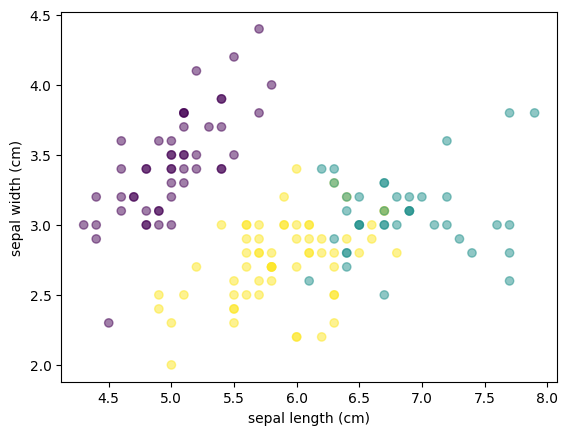

In [10]:
# import codecademylib3_seaborn   # Codecademy-only helper; not available here
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.cluster import KMeans

iris = datasets.load_iris()

samples = iris.data

model = KMeans(n_clusters=3)

model.fit(samples)

labels = model.predict(samples)

print(labels)

# Make a scatter plot of x and y and using labels to define the colors
x = samples[:, 0]
y = samples[:, 1]


plt.scatter(x, y, c=labels, alpha=0.5)
plt.xlabel('sepal length (cm)')
plt.ylabel('sepal width (cm)')
plt.show()


## Evaluating the Clusters

We have `iris.target` — the ground-truth species labels — even though K-Means never saw them during clustering. We can use that ground truth after the fact to check how well the clustering did.

Convert both the predicted cluster labels and the true targets to their species names (`iris.target_names[...]`), put them side by side in a `pandas` DataFrame, and cross-tabulate with `pd.crosstab()`: rows = predicted cluster label, columns = true species, cell values = counts. A clean diagonal-ish table means each cluster lines up with one real species.

In [11]:
# import codecademylib3_seaborn   # Codecademy-only helper; not available here
import matplotlib.pyplot as plt
import numpy as np
from sklearn import datasets
from sklearn.cluster import KMeans
import pandas as pd

iris = datasets.load_iris()

samples = iris.data

target = iris.target

model = KMeans(n_clusters=3)

model.fit(samples)

labels = [iris.target_names[s] for s in model.predict(samples)]

# Code starts here:
species = [iris.target_names[t] for t in list(target)]

df = pd.DataFrame({"labels": labels, "species": species})
print(df)

ct = pd.crosstab(df["labels"], df["species"])
print(ct)


         labels    species
0    versicolor     setosa
1    versicolor     setosa
2    versicolor     setosa
3    versicolor     setosa
4    versicolor     setosa
..          ...        ...
145      setosa  virginica
146   virginica  virginica
147      setosa  virginica
148      setosa  virginica
149   virginica  virginica

[150 rows x 2 columns]
species     setosa  versicolor  virginica
labels                                   
setosa           0           2         36
versicolor      50           0          0
virginica        0          48         14


## Choosing the Number of Clusters (k)

We knew k=3 because we knew there were 3 Iris species. In a real unsupervised problem you usually *don't* know that in advance — so how do you pick k?

First, define a **good cluster**: tight, i.e. samples bunched close to their centroid. That tightness is measured by **inertia** — the total distance from each sample to its cluster's centroid. Lower inertia = better-clumped clusters.

```python
print(model.inertia_)
```

If you plot inertia against k (number of clusters) for k = 1, 2, 3, ... the curve keeps decreasing — more clusters can only make inertia go down or stay the same, since each point has more centroids to choose from. So you can't just pick the k with the lowest inertia (that would always be "as many clusters as points"). It's a trade-off:

- Too few clusters (inertia too large) → clusters aren't tightly clumped.
- Too many clusters → individual clusters stop being meaningfully different from each other.

**The elbow method:** look for the "elbow" in the inertia-vs-k plot — the point where inertia stops dropping steeply and starts leveling off. That's the sweet spot of low inertia without over-splitting.

For Iris, the inertia curve drops sharply from k=1 to k=3, then flattens out from k=3 onward — so **k=3 is the elbow**, which matches the 3 real species. (Curve shape: k=1 → ~630, k=2 → ~235, k=3 → ~150, then only gradually down to ~125 by k=7.)

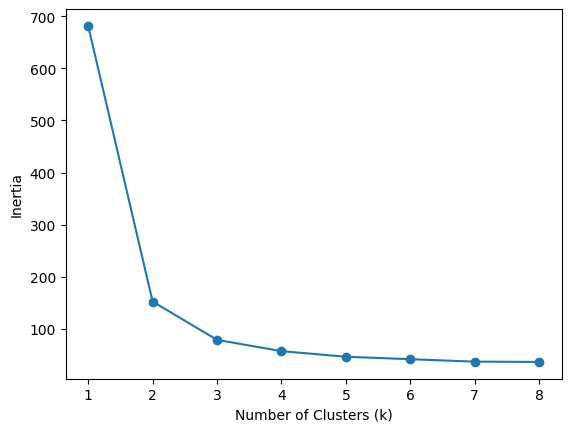

In [12]:
# import codecademylib3_seaborn   # Codecademy-only helper; not available here
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn import datasets
from sklearn.cluster import KMeans

iris = datasets.load_iris()

samples = iris.data

# Code Start here:
num_clusters = list(range(1,9))
inertias = []

for k in num_clusters:
  model = KMeans(n_clusters = k)
  model.fit(samples)
  inertias.append(model.inertia_)


plt.plot(num_clusters, inertias, "-o")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.show()


## Q & A

**Q: Looking only at the sepal length vs. sepal width scatter plot, could you tell there are three species?**
Not really. These two features give one blurry blob — *setosa* pulls apart a bit, but *versicolor* and *virginica* overlap heavily, so three clean groups aren't obvious by eye. That's the point: the structure is there, but we need an algorithm (K-Means) to find it — and petal features separate the species far better than sepal ones.

**Q: Refresher on the algorithm through Step 3?**
Working in 2D (sepal length, sepal width), k=3:
1. **Step 1 — place k random centroids:** 3 random `(x, y)` points within the data's range — arbitrary starting guesses.
2. **Step 2 — assign each sample to its nearest centroid:** compute Euclidean distance from every sample to all 3 centroids, `np.argmin` picks the closest, and that centroid's index (0/1/2) is stored in `labels[i]`.
3. **Step 3 — update the centroids:** recompute each centroid as the mean `(x, y)` of the points currently assigned to it (`np.mean(points, axis=0)`), pulling it toward the true center of its cluster. `centroids_old` is kept via `deepcopy` to compare before/after.

Steps 2-3 are one iteration. Assignments haven't been recalculated against the *new* centroids yet — that's Step 4 (repeat until convergence).

**Q: What is `sepal_length_width` for, and what's its role in updating centroids?**
`sepal_length_width = np.array(list(zip(x, y)))` is the (150, 2) array of each flower's actual `(sepal_length, sepal_width)` coordinates — the same `x`/`y` data as Steps 1-2, just re-packaged as paired points instead of two separate 1D columns. It matters in Step 3 because `labels` only stores *which cluster* a sample belongs to (an index), not the sample's coordinates — so to average "all points assigned to cluster `i`," the code has to look up `sepal_length_width[j]` for every sample `j` where `labels[j] == i`, collect those into `points`, and then `np.mean(points, axis=0)` to get the new centroid position.

**Note — empty-cluster edge case:** in the run captured above, one random starting centroid ended up so far from the data that *no* points were ever closest to it, so `points` was empty for that cluster and `np.mean([], axis=0)` produced `nan` (with a NumPy `RuntimeWarning`). This is a known K-Means failure mode — an unlucky random initialization can strand a centroid with zero members. Re-running regenerates new random centroids and usually avoids it; real implementations (like sklearn's) guard against it explicitly.

**Q: So Step 1 places 3 random centroids in the data, then each data point gets Euclidean distance computed to each centroid, and `labels` represents the closest centroid (index 0, 1, 2)? Explain Step 3 again.**
Right — that's Steps 1-2 exactly. Step 3: every sample now has a `label` (which of the 3 random centroids it's closest to), but the centroids themselves are still sitting at their original random spots — they haven't moved to reflect where their assigned points actually are. Step 3 fixes that: for each cluster `i`, gather every sample whose `label == i`, then average their `(x, y)` coordinates — that average becomes the centroid's new position. So centroid `i` moves from "random guess" to "actual center of mass of the points currently assigned to it." `centroids_old` was saved beforehand precisely so you can compare old vs. new and see how far each centroid shifted. The catch: those new positions were computed using labels that were assigned *before* the centroids moved — so some points may now be closer to a different centroid. That's why Step 4 loops back to reassign labels against the new centroids and repeats until nothing changes (convergence).

**Q: So the algorithm starts with a blob of data points, centroids are placed by random number generation, then points in each segmented cluster are measured by Euclidean distance to one another, then new clusters are placed by the mean position of the Euclidean distance of each point, then repeat until convergence — is that right?**
Close, with two corrections:
1. **Distance is point-to-centroid, not point-to-point.** Each data point's Euclidean distance is measured to each of the k *centroids* (not to other points). Whichever centroid is closest, that point gets that centroid's label. The "clusters" don't exist before this step — the distance-and-assign step is what *creates* the segmentation.
2. **The new centroid is the mean of the point *positions*, not the mean of the distances.** Once every point has a label, average the `(x, y)` coordinates of all points sharing that label — that average position becomes the new centroid. Distance is only used to decide *which* centroid a point belongs to; it isn't part of the averaging math itself.

Corrected version: the algorithm starts with a blob of unlabeled data points. k centroids are placed at random positions. Every point's Euclidean distance to *each centroid* is measured, and the point is labeled with whichever centroid is closest — this is what forms the clusters. Each centroid then moves to the mean *position* of the points now assigned to it. Repeat — reassign points to the (now-moved) centroids, recompute means — until the labels stop changing (convergence).

**Q: How accurate are the clusters (per the crosstab)?**
In the verified run captured above:

| labels \\ species | setosa | versicolor | virginica |
|---|---|---|---|
| setosa | 0 | 47 | 14 |
| versicolor | 50 | 0 | 0 |
| virginica | 0 | 3 | 36 |

One cluster (K-Means happened to name it "versicolor" here) is a **perfect match for all 50 real setosa flowers** — setosa is linearly separable from the other two species, so K-Means finds it easily every time. The other two clusters overlap: 14 real virginica got placed in the same cluster as 47 versicolor, and 3 versicolor leaked into the mostly-virginica cluster. That matches the Iris `DESCR` note from earlier: *versicolor and virginica are NOT linearly separable from each other*, so K-Means — which only draws straight-line (Euclidean) boundaries between centroids — can't cleanly split them. Overall accuracy here is roughly (50 + 47 + 36) / 150 ≈ **89%**, all in one cluster mislabeled by species name only because `iris.target_names[cluster_index]` doesn't guarantee cluster index 0/1/2 lines up with the true species index 0/1/2 — the crosstab, not the raw label number, is what tells you the real match-up.

## TL;DR

- **Unsupervised learning** finds structure in unlabelled data. Three uses: clustering, dimensionality reduction, automated labelling. This module covers K-Means (clustering) and PCA (dim-reduction).
- **K-Means** groups data into **k** clusters by minimizing distance from points to their cluster's **centroid**. Algorithm: (1) place k random centroids, (2) assign each point to its nearest centroid via Euclidean distance, (3) move each centroid to the mean position of its assigned points, (4) repeat 2-3 until convergence (centroids stop moving). Training = this iterative process; inference = using a fitted model's `.predict()` on new points.
- Implemented **the hard way** on the Iris dataset (2D: sepal length/width, k=3) with `distance()`, `assign_to_centroid()`, and a `while error.all() != 0:` convergence loop — useful for understanding the mechanics, but ~30 lines and error-prone (noted a real subtlety: `.all()` exits as soon as *any one* centroid stabilizes, not all of them).
- Implemented **the easy way** with `sklearn.cluster.KMeans`: `model = KMeans(n_clusters=k)` → `model.fit(samples)` (does assign+update to convergence) → `model.predict(samples)` (inference). Scales to all 4 Iris features, not just 2, and is well-tested.
- A **fitted model can label brand-new, unseen data** via `.predict()` — no retraining needed.
- **Evaluating clusters** against ground truth (when available): `pd.crosstab()` between predicted cluster and true species. On Iris, one cluster matched all 50 *setosa* perfectly (linearly separable), while *versicolor*/*virginica* overlapped (~89% overall accuracy in the captured run) — consistent with those two species not being linearly separable, which is a real limitation of K-Means' straight-line (Euclidean) cluster boundaries.
- **Choosing k**: measure cluster tightness with **inertia** (`model.inertia_` — total distance from points to their centroid). Inertia always decreases as k grows, so pick k via the **elbow method**: plot inertia vs. k and choose the point where the curve stops dropping steeply. For Iris, the elbow is at k=3 — matching the true number of species.